# MeanShift and CamShift Tracking with OpenCV

## Aim
Test OpenCV's MeanShift and CamShift tracking on a sample video, show the results, and compare them.

## What this notebook does
1. Load a video.
2. Select an object to track in the first frame.
3. Build the target histogram from the ROI.
4. Run MeanShift tracking.
5. Run CamShift tracking.
6. Save results and display sample frames.
7. Write short comments for the report.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

plt.rcParams["figure.figsize"] = (10, 6)

output_dir = Path("output_meanshift_camshift")
output_dir.mkdir(exist_ok=True)

# Change this to your dataset video path
video_path = "input_video.mp4"

if not os.path.exists(video_path):
    raise FileNotFoundError(f"Video not found: {video_path}")

print("Output folder:", output_dir.resolve())
print("Video path:", Path(video_path).resolve())

Output folder: C:\Users\Shenal\Documents\dex\CV3\output_meanshift_camshift
Video path: C:\Users\Shenal\Documents\dex\CV3\input_video.mp4


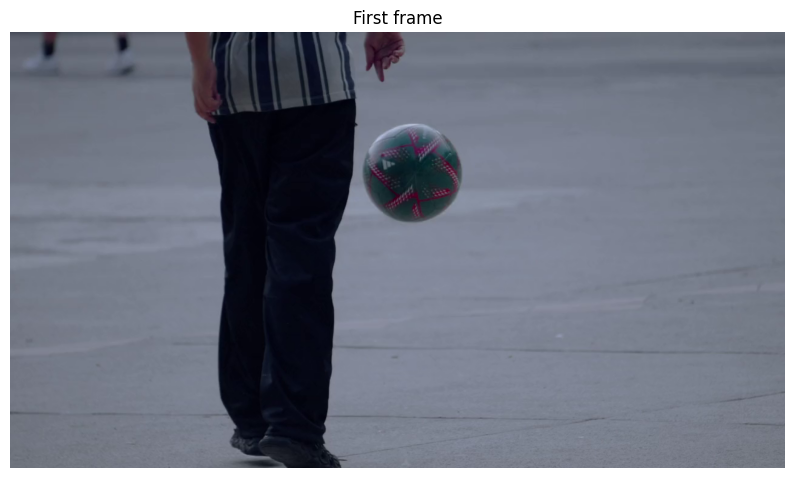

Frame shape: (720, 1280, 3)


In [2]:
def show_bgr(img, title="Image", cmap=None):
    if len(img.shape) == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

cap = cv2.VideoCapture(video_path)
ret, first_frame = cap.read()
cap.release()

if not ret:
    raise ValueError("Could not read the first frame from the video.")

show_bgr(first_frame, "First frame")
print("Frame shape:", first_frame.shape)

## Set the initial ROI

Run Cell 3 and look at the first frame.

Then manually set:
- x = left
- y = top
- w = width
- h = height

Choose the object you want to track, for example a face, car, or ball.

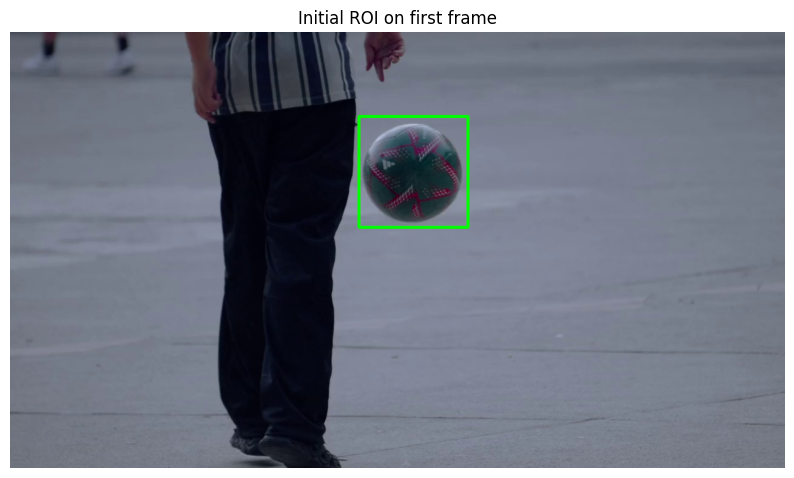

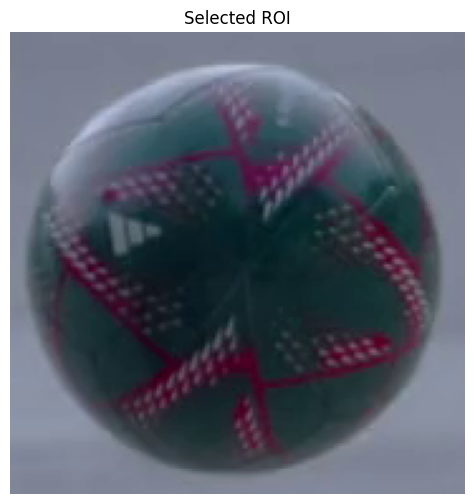

In [3]:
x, y, w, h = 576, 139, 180, 183

track_window = (x, y, w, h)

frame_with_roi = first_frame.copy()
cv2.rectangle(frame_with_roi, (x, y), (x + w, y + h), (0, 255, 0), 4)
show_bgr(frame_with_roi, "Initial ROI on first frame")

roi = first_frame[y:y+h, x:x+w]
show_bgr(roi, "Selected ROI")




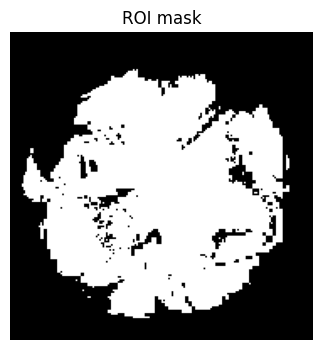

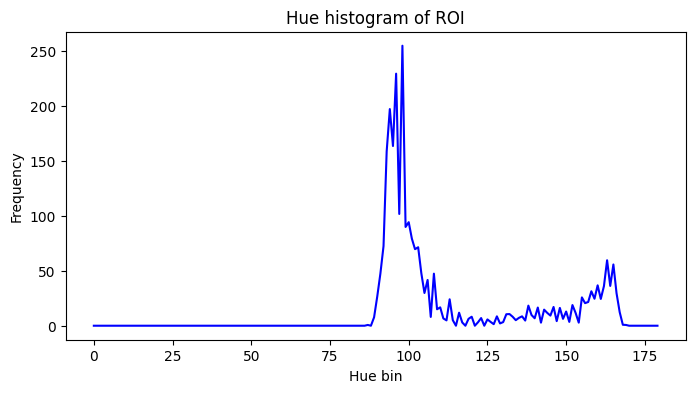

In [4]:
# Build histogram from ROI using HSV
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

# Mask low-light / poor pixels
lower = np.array((0., 60., 32.))
upper = np.array((180., 255., 255.))
mask = cv2.inRange(roi_hsv, lower, upper)

# Histogram of Hue channel
roi_hist = cv2.calcHist([roi_hsv], [0], mask, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

# Termination criteria
term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

# Visualize mask and histogram
plt.figure(figsize=(6, 4))
plt.imshow(mask, cmap="gray")
plt.title("ROI mask")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(roi_hist, color="blue")
plt.title("Hue histogram of ROI")
plt.xlabel("Hue bin")
plt.ylabel("Frequency")
plt.show()

In [ ]:
def run_meanshift(video_path, roi_hist, init_window, term_crit, output_name="meanshift_output.mp4"):
    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0:
        fps = 25

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out_path = output_dir / output_name
    writer = cv2.VideoWriter(
        str(out_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    track_window = init_window
    frame_idx = 0
    sample_indices = {0, 20, 40, 60}
    samples = []
    boxes = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        back_proj = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)

        _, track_window = cv2.meanShift(back_proj, track_window, term_crit)
        x, y, w, h = track_window
        boxes.append((frame_idx, x, y, w, h))

        result = frame.copy()
        cv2.rectangle(result, (x, y), (x + w, y + h), (255, 0, 0), 2)
        writer.write(result)

        if frame_idx in sample_indices:
            samples.append({
                "frame_idx": frame_idx,
                "input": frame.copy(),
                "back_proj": back_proj.copy(),
                "output": result.copy()
            })

        frame_idx += 1

    cap.release()
    writer.release()
    return out_path, samples, boxes

meanshift_video, meanshift_samples, meanshift_boxes = run_meanshift(
    video_path, roi_hist, track_window, term_crit
)

print("Saved:", meanshift_video)
print("Sample frames collected:", len(meanshift_samples))

In [86]:
def run_camshift(video_path, roi_hist, init_window, term_crit, output_name="camshift_output.mp4"):
    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0:
        fps = 25

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out_path = output_dir / output_name
    writer = cv2.VideoWriter(
        str(out_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    track_window = init_window
    frame_idx = 0
    sample_indices = {0, 20, 40, 60}
    samples = []
    rotated_boxes = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        back_proj = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)

        ret_cam, track_window = cv2.CamShift(back_proj, track_window, term_crit)
        pts = cv2.boxPoints(ret_cam)
        pts = np.int32(pts)

        rotated_boxes.append({
            "frame_idx": frame_idx,
            "center": ret_cam[0],
            "size": ret_cam[1],
            "angle": ret_cam[2]
        })

        result = frame.copy()
        cv2.polylines(result, [pts], True, (0, 255, 0), 2)
        writer.write(result)

        if frame_idx in sample_indices:
            samples.append({
                "frame_idx": frame_idx,
                "input": frame.copy(),
                "back_proj": back_proj.copy(),
                "output": result.copy()
            })

        frame_idx += 1

    cap.release()
    writer.release()
    return out_path, samples, rotated_boxes

camshift_video, camshift_samples, camshift_boxes = run_camshift(
    video_path, roi_hist, track_window, term_crit
)

print("Saved:", camshift_video)
print("Sample frames collected:", len(camshift_samples))


Saved: output_meanshift_camshift\camshift_output.mp4
Sample frames collected: 4


In [87]:
# Save sample output images for the report
for s in meanshift_samples:
    out_file = output_dir / f"meanshift_frame_{s['frame_idx']}.png"
    cv2.imwrite(str(out_file), s["output"])

for s in camshift_samples:
    out_file = output_dir / f"camshift_frame_{s['frame_idx']}.png"
    cv2.imwrite(str(out_file), s["output"])

print("Saved sample PNG frames to:", output_dir.resolve())

Saved sample PNG frames to: C:\Users\Public\Downloads\CV3\output_meanshift_camshift


In [87]:
# Simple numerical summary for discussion
mean_w = np.mean([b[3] for b in meanshift_boxes]) if meanshift_boxes else 0
mean_h = np.mean([b[4] for b in meanshift_boxes]) if meanshift_boxes else 0

cam_w = np.mean([b["size"][0] for b in camshift_boxes]) if camshift_boxes else 0
cam_h = np.mean([b["size"][1] for b in camshift_boxes]) if camshift_boxes else 0
cam_angle = np.mean([b["angle"] for b in camshift_boxes]) if camshift_boxes else 0

print("MeanShift average box width :", round(mean_w, 2))
print("MeanShift average box height:", round(mean_h, 2))
print("CamShift average box width  :", round(cam_w, 2))
print("CamShift average box height :", round(cam_h, 2))
print("CamShift average angle      :", round(cam_angle, 2))

MeanShift average box width : 100.0
MeanShift average box height: 100.0
CamShift average box width  : 151.4
CamShift average box height : 194.97
CamShift average angle      : 70.34


In [99]:
import pandas as pd
import numpy as np

# Use values already computed in your notebook
mean_w = np.mean([b[3] for b in meanshift_boxes]) if meanshift_boxes else 0
mean_h = np.mean([b[4] for b in meanshift_boxes]) if meanshift_boxes else 0
cam_w = np.mean([b["size"][0] for b in camshift_boxes]) if camshift_boxes else 0
cam_h = np.mean([b["size"][1] for b in camshift_boxes]) if camshift_boxes else 0
cam_angle = np.mean([b["angle"] for b in camshift_boxes]) if camshift_boxes else 0

comparison_df = pd.DataFrame({
    "Feature": [
        "Window size",
        "Rotation handling",
        "Scale handling",
        "Avg box size (our run)",
        "Avg rotation angle",
        "Complexity",
        "Best use case",
        "Output representation"
    ],
    "MeanShift": [
        "Fixed throughout",
        "No — always axis-aligned rectangle",
        f"No — fixed {mean_w:.0f}×{mean_h:.0f} px box",
        f"{mean_w:.0f} × {mean_h:.0f} px (unchanged)",
        "0° (fixed)",
        "Simpler and faster",
        "Objects with constant size & orientation",
        "Axis-aligned rectangle (x, y, w, h)"
    ],
    "CamShift": [
        "Adapts dynamically",
        "Yes — returns rotated bounding box",
        "Yes — box grows/shrinks with object",
        f"~{cam_w:.0f} × {cam_h:.0f} px",
        f"~{cam_angle:.1f}°",
        "Slightly more computationally intensive",
        "Objects that change scale or rotate",
        "Rotated ellipse / polygon with angle"
    ]
})

display(comparison_df)

,Feature,MeanShift,CamShift
0,Window size,Fixed throughout,Adapts dynamically
1,Rotation handling,No — always axis-aligned rectangle,Yes — returns rotated bounding box
2,Scale handling,No — fixed 100×100 px box,Yes — box grows/shrinks with object
3,Avg box size (our run),100 × 100 px (unchanged),~151 × 195 px
4,Avg rotation angle,0° (fixed),~70.3°
5,Complexity,Simpler and faster,Slightly more computationally intensive
6,Best use case,Objects with constant size & orientation,Objects that change scale or rotate
7,Output representation,"Axis-aligned rectangle (x, y, w, h)",Rotated ellipse / polygon with angle


## Comments for the report

### MeanShift
- MeanShift tracked the object by moving a fixed-size window toward the region with the highest probability in the backprojection image.
- It worked reasonably well when the object size stayed almost constant.
- A limitation was that the window size did not change, so it may become less accurate when the target moves closer, farther, or rotates.

### CamShift
- CamShift gave better results when the object changed size or orientation.
- It returned a rotated box, which made tracking more flexible than MeanShift.
- It was more suitable for realistic video scenes where the target scale changes over time.

### Overall comparison
- MeanShift is simpler and easier to understand.
- CamShift is usually more practical for object tracking in videos because it adapts the search window.
- Both methods depend heavily on a good initial ROI and a useful color histogram.